# E-Commerce Price Prediction - Model Training & Validation

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import catboost as cat
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [2]:
# Import datasets

train_df = pd.read_csv('./ecommerce_price_prediction-train.csv')
test_df = pd.read_csv('./ecommerce_price_prediction-test-3-days.csv')

## Exploratory Data Analysis + Data Preprocessing

In [3]:
# check dataset info

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306226 entries, 0 to 306225
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   capturedAt                306226 non-null  object 
 1   shopId                    306226 non-null  int64  
 2   itemId                    306226 non-null  int64  
 3   modelId                   306226 non-null  int64  
 4   price                     306226 non-null  int64  
 5   priceBeforeDiscount       306226 non-null  int64  
 6   promotionId               306226 non-null  int64  
 7   cat_id                    306226 non-null  int64  
 8   stock                     3738 non-null    float64
 9   normal_stock              3738 non-null    float64
 10  raw_discount              306226 non-null  int64  
 11  show_discount             306226 non-null  int64  
 12  brand                     200562 non-null  object 
 13  is_free_shipping          306226 non-null  o

In [4]:
# check dataset statistics

train_df.describe()

,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,stock,normal_stock,raw_discount,show_discount,item_price_min,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count
count,3.062260e+05,3.062260e+05,3.062260e+05,3.062260e+05,3.062260e+05,3.062260e+05,306226.000000,3738.0,3738.0,306226.000000,306226.000000,3.062260e+05,3.062260e+05,306226.000000,306226.000000,306226.000000,306226.000000,305027.000000,306226.000000
mean,6.476090e+08,1.938585e+10,1.651984e+11,5.234146e+07,1.885758e+07,1.958224e+14,100432.188472,0.0,0.0,20.499598,20.499598,4.536168e+07,5.965785e+07,4.657069,92.299609,87.292986,4.948080,78.112954,4202.578909
std,4.658536e+08,8.466663e+09,7.341994e+10,9.137196e+07,5.101101e+07,2.605581e+14,291.360308,0.0,0.0,28.531341,28.531341,8.420521e+07,9.787515e+07,1.178862,319.878155,311.354822,0.038938,16.476535,13901.193286
min,1.000692e+06,6.632660e+07,5.246531e+07,1.000000e+05,0.000000e+00,0.000000e+00,100001.000000,0.0,0.0,0.000000,0.000000,1.000000e+05,1.000000e+05,0.000000,0.000000,0.000000,4.500000,9.000000,0.000000
25%,1.002919e+08,1.693105e+10,1.185036e+11,9.900000e+06,0.000000e+00,0.000000e+00,100015.000000,0.0,0.0,0.000000,0.000000,7.900000e+06,1.200000e+07,4.937500,4.000000,4.000000,4.938632,66.000000,216.000000
50%,1.002937e+09,2.247004e+10,1.853718e+11,2.050000e+07,0.000000e+00,0.000000e+00,100631.000000,0.0,0.0,0.000000,0.000000,1.650000e+07,2.590000e+07,4.985000,16.000000,15.000000,4.956926,82.000000,882.000000
75%,1.006572e+09,2.496184e+10,2.239639e+11,5.900000e+07,1.990000e+07,5.352425e+14,100636.000000,0.0,0.0,44.000000,44.000000,5.000000e+07,6.690000e+07,5.000000,64.000000,57.000000,4.972853,92.000000,3558.000000
max,1.206969e+09,2.996089e+10,2.578970e+11,1.660000e+09,1.299000e+09,6.135842e+14,100644.000000,0.0,0.0,88.000000,88.000000,1.660000e+09,1.660000e+09,5.000000,15462.000000,15309.000000,5.000000,100.000000,206855.000000


In [5]:
# both stock and normal_stock contains no useful data (either zero or missing), so we can just drop it

train_df = train_df.drop(['stock', 'normal_stock'], axis = 1)
train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,show_discount,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,534463751667712,100630,38,38,...,41900000,0.000000,0,0,4.975239,55.0,158,f,f,f
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,474465164066816,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f


In [6]:
# since the null values count are small enough, we can impute the shop response rate data

train_df["shop_response_rate"].fillna(train_df["shop_response_rate"].mean(),inplace = True)
train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,show_discount,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,534463751667712,100630,38,38,...,41900000,0.000000,0,0,4.975239,55.0,158,f,f,f
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,474465164066816,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,t,f,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,f,f,f


In [7]:
# change data from "boolean" string to integer

onehot_cols = ["is_free_shipping", "is_pre_order", "is_official_shop", "is_verified", "is_preferred_plus_seller"]

for col in onehot_cols:
  train_df[col] = train_df[col].apply(lambda x : 1 if x == 't' else 0)

train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,show_discount,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,534463751667712,100630,38,38,...,41900000,0.000000,0,0,4.975239,55.0,158,0,0,0
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,474465164066816,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,0,0,100013,14,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,0,100001,0,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0


In [8]:
# convert "missing" data to null values, we can do this as we are going to use models that can handle null values

train_df['raw_discount'] = np.where(train_df['raw_discount'] == 0, np.nan, train_df['raw_discount'])
train_df['promotionId'] = np.where(train_df['promotionId'] == 0, np.nan, train_df['promotionId'])

train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,show_discount,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,5.344638e+14,100630,38.0,38,...,41900000,0.000000,0,0,4.975239,55.0,158,0,0,0
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,0,NaN,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,4.744652e+14,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,0,NaN,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,0,NaN,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,0,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,0,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,0,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0


In [9]:
# set priceBeforeDiscount into original price if no discount

train_df['priceBeforeDiscount'] = np.where(train_df['priceBeforeDiscount'] == 0, train_df['price'], train_df['priceBeforeDiscount'])

train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,show_discount,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,5.344638e+14,100630,38.0,38,...,41900000,0.000000,0,0,4.975239,55.0,158,0,0,0
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,16900000,NaN,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,4.744652e+14,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,16900000,NaN,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,16900000,NaN,100013,14.0,14,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,16500000,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,15900000,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000,NaN,100001,NaN,0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0


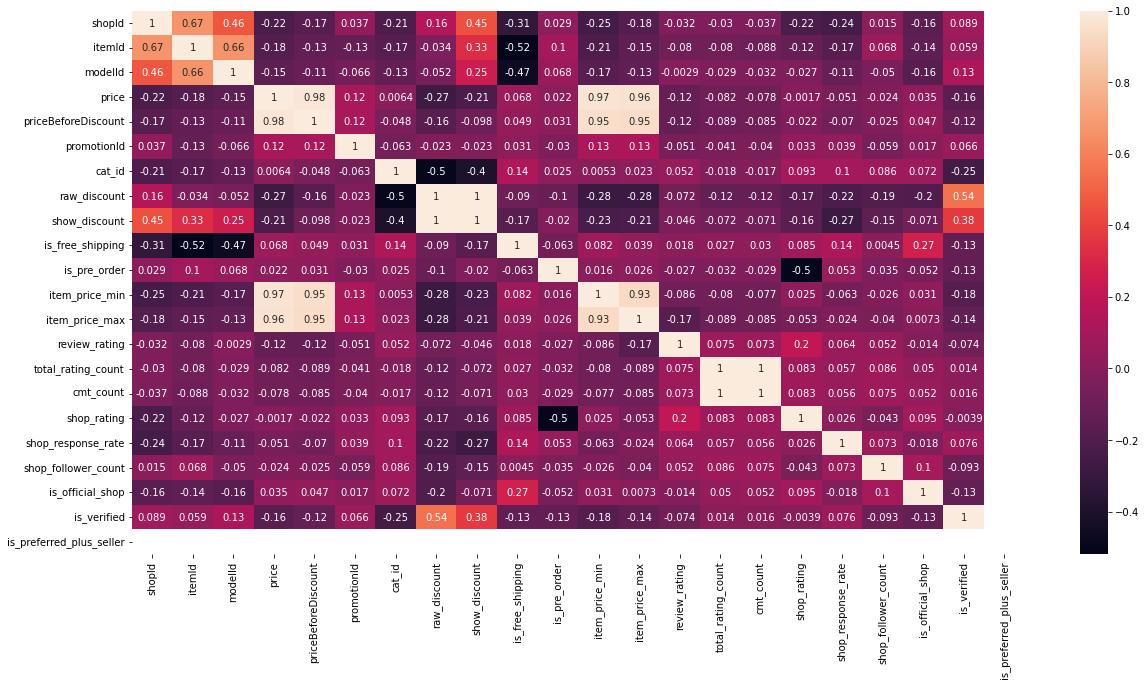

In [10]:
# correlation analysis

plt.figure(figsize=(20,10))
sns.heatmap(train_df.corr(), annot=True)
plt.show()

In [11]:
# high correlation with raw_discount, we can drop show_discount

train_df = train_df.drop(['show_discount'], axis = 1)
train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,5.344638e+14,100630,38.0,MlRAE 未來美,...,41900000,0.000000,0,0,4.975239,55.0,158,0,0,0
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,16900000,NaN,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,4.744652e+14,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,16900000,NaN,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,16900000,NaN,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,16500000,NaN,100001,NaN,POLIDENT 保麗淨,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,15900000,NaN,100001,NaN,POLIDENT 保麗淨,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000,NaN,100001,NaN,POLIDENT 保麗淨,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000,NaN,100001,NaN,POLIDENT 保麗淨,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0


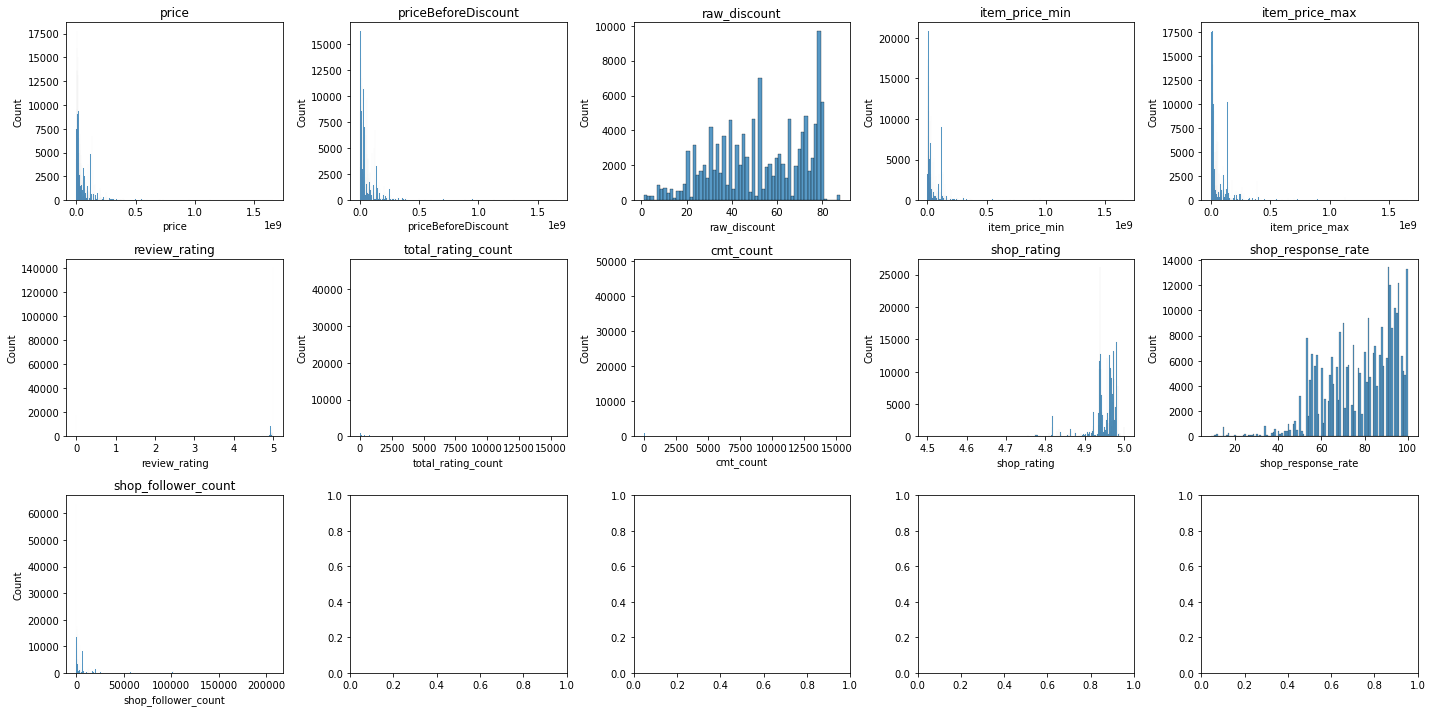

In [12]:
# histogram plot

num_cols = []
cat_cols = ['capturedAt', 'shopId', 'itemId', 'modelId', 'promotionId', 'cat_id', 'brand']

for col in onehot_cols:
  cat_cols.append(col)

for col in train_df.columns:
  if col not in cat_cols:
    num_cols.append(col)

fig, axes = plt.subplots(nrows = 3, ncols = 5, figsize = (20,10), sharex = False, sharey = False)
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(data = train_df[col], kde = False, ax = axes[i])
  axes[i].set_title(col)
  # axes[i].set_ylim(0, 25000)

plt.tight_layout()
plt.show()

In [13]:
# encoding values for 'brand'

enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=np.nan
)

train_df['brand'] = enc.fit_transform(train_df[['brand']])
train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,5.344638e+14,100630,38.0,157.0,...,41900000,0.000000,0,0,4.975239,55.0,158,0,0,0
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,16900000,NaN,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,4.744652e+14,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,16900000,NaN,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,16900000,NaN,100013,14.0,NaN,...,14900000,5.000000,1,1,4.936441,70.0,3955,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,16500000,NaN,100001,NaN,189.0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,15900000,NaN,100001,NaN,189.0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000,NaN,100001,NaN,189.0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000,NaN,100001,NaN,189.0,...,38500000,4.972816,515,473,4.973416,96.0,3927,0,0,0


In [14]:
# save encoder model for testing phase

filename = 'brand_encoder.pkl'

with open(filename,'wb') as file:
    pkl.dump(enc,file)

In [15]:
# augment the dataset with copies of data where the values of some features are missing

train_df_miss = train_df.copy()
cnt_cols = len(train_df_miss.columns)

for i in range(5,cnt_cols):
    col = train_df_miss.columns[i]
    idx = train_df_miss.sample(frac = 0.5, random_state = 42).index
    train_df_miss.loc[idx,col] = np.nan
    
train_df = pd.concat((train_df, train_df_miss), axis = 0)
train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000.0,5.344638e+14,100630.0,38.0,157.0,...,41900000.0,0.000000,0.0,0.0,4.975239,55.0,158.0,0.0,0.0,0.0
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,14900000.0,5.000000,1.0,1.0,4.936441,70.0,3955.0,1.0,0.0,0.0
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000.0,4.744652e+14,100013.0,14.0,NaN,...,14900000.0,5.000000,1.0,1.0,4.936441,70.0,3955.0,1.0,0.0,0.0
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,14900000.0,5.000000,1.0,1.0,4.936441,70.0,3955.0,1.0,0.0,0.0
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,14900000.0,5.000000,1.0,1.0,4.936441,70.0,3955.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,16500000.0,NaN,100001.0,NaN,189.0,...,38500000.0,4.972816,515.0,473.0,4.973416,96.0,3927.0,0.0,0.0,0.0
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000.0,NaN,100001.0,NaN,189.0,...,38500000.0,4.972816,515.0,473.0,4.973416,96.0,3927.0,0.0,0.0,0.0


## Feature Engineering

In [16]:
# add 'is_missing' features, useful for tree-based models

for col in train_df.columns:
    if col=='capturedAt' or col=='shopId' or col=='itemId' or col=='modelId' or col=='price' :
        continue
    col_name = str(col) + "_is_missing"
    train_df[col_name] = train_df[col].isna().astype(int)
    
train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,...,item_price_max_is_missing,review_rating_is_missing,total_rating_count_is_missing,cmt_count_is_missing,shop_rating_is_missing,shop_response_rate_is_missing,shop_follower_count_is_missing,is_official_shop_is_missing,is_verified_is_missing,is_preferred_plus_seller_is_missing
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000.0,5.344638e+14,100630.0,38.0,157.0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000.0,4.744652e+14,100013.0,14.0,NaN,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,2025-03-22 04:27:05.302,1009757562,26058443824,246415388990,16500000,16500000.0,NaN,100001.0,NaN,189.0,...,0,0,0,0,0,0,0,0,0,0
306222,2025-03-22 04:27:05.302,1009757562,26058443824,207734010381,15900000,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
306223,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
306224,2025-03-22 04:27:05.302,1009757562,26058443824,207734010380,29100000,29100000.0,NaN,100001.0,NaN,189.0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# engineering new features from timestamp data

train_df['capturedAt'] = pd.to_datetime(train_df['capturedAt'])
train_df['day_of_week'] = train_df['capturedAt'].dt.dayofweek
train_df['hour'] = train_df['capturedAt'].dt.hour
train_df['minute'] = train_df['capturedAt'].dt.minute
train_df['is_holiday'] = np.where(train_df['day_of_week'] >= 5, 1, 0)
train_df['capturedAt'] = train_df['capturedAt'].astype('int64') // 10**6

train_df

C:\Users\Greg\AppData\Local\Temp/ipykernel_10496/4030103575.py:8: FutureWarning: casting datetime64[ns] values to int64 with .astype(...) is deprecated and will raise in a future version. Use .view(...) instead.
  train_df['capturedAt'] = train_df['capturedAt'].astype('int64') // 10**6


,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,...,shop_rating_is_missing,shop_response_rate_is_missing,shop_follower_count_is_missing,is_official_shop_is_missing,is_verified_is_missing,is_preferred_plus_seller_is_missing,day_of_week,hour,minute,is_holiday
0,1735771056424,1008004,29302587134,185168612932,41900000,68000000.0,5.344638e+14,100630.0,38.0,157.0,...,0,0,0,0,0,0,2,22,37,0
1,1735782348634,1006671485,18087284916,166287259494,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,0,0,0,0,0,0,3,1,45,0
2,1735782348634,1006671485,18087284916,166287259497,11900000,13900000.0,4.744652e+14,100013.0,14.0,NaN,...,0,0,0,0,0,0,3,1,45,0
3,1735782348634,1006671485,18087284916,166287259492,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,0,0,0,0,0,0,3,1,45,0
4,1735782348634,1006671485,18087284916,166287259490,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,0,0,0,0,0,0,3,1,45,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306221,1742617625302,1009757562,26058443824,246415388990,16500000,16500000.0,NaN,100001.0,NaN,189.0,...,0,0,0,0,0,0,5,4,27,1
306222,1742617625302,1009757562,26058443824,207734010381,15900000,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,5,4,27,1
306223,1742617625302,1009757562,26058443824,207734010380,29100000,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,5,4,27,1
306224,1742617625302,1009757562,26058443824,207734010380,29100000,29100000.0,NaN,100001.0,NaN,189.0,...,0,0,0,0,0,0,5,4,27,1


In [18]:
# engineering new features based on shop and item data

item_stats = train_df.groupby('itemId')['price'].agg(['mean','std'])
item_stats.columns = ['item_price_mean', 'item_price_std']

shop_stats = train_df.groupby('shopId')['price'].agg(['mean','std'])
shop_stats.columns = ['shop_price_mean', 'shop_price_std']

shop_disc_stats = train_df.groupby('shopId')['raw_discount'].agg(['mean','count'])
shop_disc_stats.columns = ['shop_discount_mean','shop_discount_count']

train_df = train_df.merge(item_stats, on='itemId', how='left')
train_df = train_df.merge(shop_stats, on='shopId', how='left')
train_df = train_df.merge(shop_disc_stats, on='shopId', how='left')

train_df

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,...,day_of_week,hour,minute,is_holiday,item_price_mean,item_price_std,shop_price_mean,shop_price_std,shop_discount_mean,shop_discount_count
0,1735771056424,1008004,29302587134,185168612932,41900000,68000000.0,5.344638e+14,100630.0,38.0,157.0,...,2,22,37,0,4.127500e+07,9.343532e+05,4.362222e+07,1.143164e+07,38.040000,50
1,1735782348634,1006671485,18087284916,166287259494,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
2,1735782348634,1006671485,18087284916,166287259497,11900000,13900000.0,4.744652e+14,100013.0,14.0,NaN,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
3,1735782348634,1006671485,18087284916,166287259492,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
4,1735782348634,1006671485,18087284916,166287259490,16900000,16900000.0,NaN,100013.0,14.0,NaN,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612447,1742617625302,1009757562,26058443824,246415388990,16500000,16500000.0,NaN,100001.0,NaN,189.0,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139
612448,1742617625302,1009757562,26058443824,207734010381,15900000,NaN,NaN,NaN,NaN,NaN,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139
612449,1742617625302,1009757562,26058443824,207734010380,29100000,NaN,NaN,NaN,NaN,NaN,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139
612450,1742617625302,1009757562,26058443824,207734010380,29100000,29100000.0,NaN,100001.0,NaN,189.0,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139


## Model Training

In [19]:
# feature-target split

X = train_df.drop("price", axis = 1)
y = train_df['price']

X

,capturedAt,shopId,itemId,modelId,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,is_free_shipping,...,day_of_week,hour,minute,is_holiday,item_price_mean,item_price_std,shop_price_mean,shop_price_std,shop_discount_mean,shop_discount_count
0,1735771056424,1008004,29302587134,185168612932,68000000.0,5.344638e+14,100630.0,38.0,157.0,0.0,...,2,22,37,0,4.127500e+07,9.343532e+05,4.362222e+07,1.143164e+07,38.040000,50
1,1735782348634,1006671485,18087284916,166287259494,16900000.0,NaN,100013.0,14.0,NaN,0.0,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
2,1735782348634,1006671485,18087284916,166287259497,13900000.0,4.744652e+14,100013.0,14.0,NaN,0.0,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
3,1735782348634,1006671485,18087284916,166287259492,16900000.0,NaN,100013.0,14.0,NaN,0.0,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
4,1735782348634,1006671485,18087284916,166287259490,16900000.0,NaN,100013.0,14.0,NaN,0.0,...,3,1,45,0,1.501111e+07,2.284705e+06,1.953543e+08,2.228411e+08,19.873706,1449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612447,1742617625302,1009757562,26058443824,246415388990,16500000.0,NaN,100001.0,NaN,189.0,0.0,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139
612448,1742617625302,1009757562,26058443824,207734010381,NaN,NaN,NaN,NaN,NaN,NaN,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139
612449,1742617625302,1009757562,26058443824,207734010380,NaN,NaN,NaN,NaN,NaN,NaN,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139
612450,1742617625302,1009757562,26058443824,207734010380,29100000.0,NaN,100001.0,NaN,189.0,0.0,...,5,4,27,1,2.564200e+07,8.444936e+06,2.257315e+07,2.760752e+07,4.516242,1139


In [20]:
# train-test split

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size = 0.25, random_state = 42, shuffle = True)

X_train

,capturedAt,shopId,itemId,modelId,priceBeforeDiscount,promotionId,cat_id,raw_discount,brand,is_free_shipping,...,day_of_week,hour,minute,is_holiday,item_price_mean,item_price_std,shop_price_mean,shop_price_std,shop_discount_mean,shop_discount_count
247271,1742006113099,1001818098,22769469328,240555656384,130000000.0,NaN,100632.0,NaN,133.0,0.0,...,5,2,35,1,1.283333e+08,5.527928e+06,1.138073e+08,5.146833e+07,NaN,0
64066,1739788358037,1008840284,24081826662,99580326567,6000000.0,5.266242e+14,100631.0,73.0,NaN,0.0,...,0,10,32,0,1.600000e+06,0.000000e+00,1.600000e+06,0.000000e+00,73.000000,528
556889,1742064305226,10075419,10809714908,55823512434,7900000.0,NaN,100001.0,NaN,NaN,0.0,...,5,18,45,1,7.900000e+06,0.000000e+00,1.295574e+07,5.109607e+06,34.000000,107
474636,1741150113716,1007848,21029838337,145363729911,3500000.0,NaN,100011.0,NaN,NaN,0.0,...,2,4,48,0,3.500000e+06,0.000000e+00,3.500000e+06,0.000000e+00,NaN,0
352819,1739447810772,100423447,2478343015,5257178656,NaN,NaN,NaN,NaN,NaN,NaN,...,3,11,56,0,2.300000e+07,0.000000e+00,1.667914e+07,7.934284e+06,27.152331,1523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,1740564907150,1002597502,25550156734,255003949644,7800000.0,NaN,100636.0,NaN,316.0,0.0,...,2,10,15,0,7.800000e+06,0.000000e+00,1.678396e+07,1.698644e+07,15.690355,2167
259178,1742164845578,1005099271,23176798963,256519597707,39900000.0,5.475751e+14,100015.0,63.0,NaN,0.0,...,6,22,40,1,1.656667e+07,2.357530e+06,1.519001e+07,1.254718e+07,70.296146,79427
365838,1739698323504,10026294,15146482341,123996040399,61700000.0,NaN,100636.0,NaN,NaN,0.0,...,6,9,32,1,5.336667e+07,9.884389e+06,4.070000e+07,2.192905e+07,NaN,0
131932,1740789758837,10018921,24964796266,178074689300,18000000.0,NaN,100631.0,NaN,2.0,0.0,...,5,0,42,1,2.200000e+07,2.830256e+06,9.306027e+07,6.085351e+07,NaN,0


In [21]:
# list of models to be trained and compared

model_list = [
    {
        'name': "Decision Tree",
        'model': DecisionTreeRegressor(criterion='squared_error')
    },
    {
        'name': "Random Forest",
        'model': RandomForestRegressor(n_estimators=101, criterion='squared_error')
    },
    {
        'name': "XGBoost",
        'model': xgb.XGBRegressor(eta=0.01, n_estimators=101, reg_alpha=1)
    },
    {
        'name': "CatBoost",
        'model': cat.CatBoostRegressor(learning_rate=0.01, n_estimators=101)
    }
]

In [22]:
# model training

best_model = None
best_mape = np.inf
best_model_name = None
# best_model_parameters = None

def model_training (model, name):
    global best_mape, best_model, best_model_name, best_model_parameters
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    model_rmse = root_mean_squared_error(y_val, y_pred)
    model_mae = mean_absolute_error(y_val, y_pred)
    model_r2_score = r2_score(y_val, y_pred)
    model_mape = mean_absolute_percentage_error(y_val, y_pred)
    print("Model name: " + str(name))
    print("RMSE: " + str(model_rmse))
    print("MAE: " + str(model_mae))
    print("MAPE: " + str(model_mape))
    print("R-squared: " + str(model_r2_score))
    if (best_mape > model_mape):
        best_mape = model_mape
        best_model = model
        best_model_name = name

for model in model_list:
    model_training(model['model'], model['name'])
    print()

print("Best model: " + str(best_model_name))
print("Best MAPE: " + str(best_mape))

Model name: Decision Tree
RMSE: 8049286.9101729505
MAE: 1387607.8051778497
MAPE: 0.05295311329246831
R-squared: 0.992379874264872

Model name: Random Forest
RMSE: 7377457.725714302
MAE: 1347711.6776200943
MAPE: 0.05181404904960241
R-squared: 0.9935988090710357

Model name: XGBoost
RMSE: 35172884.0
MAE: 19299514.0
MAPE: 1.557740569114685
R-squared: 0.8544999361038208

0:	learn: 90266633.3448772	total: 228ms	remaining: 22.8s
1:	learn: 89453952.8689860	total: 283ms	remaining: 14s
2:	learn: 88641355.9736462	total: 339ms	remaining: 11.1s
3:	learn: 87837295.4496170	total: 401ms	remaining: 9.71s
4:	learn: 87042213.2906832	total: 467ms	remaining: 8.97s
5:	learn: 86257332.9283167	total: 525ms	remaining: 8.31s
6:	learn: 85479260.1716283	total: 583ms	remaining: 7.83s
7:	learn: 84712795.4594183	total: 641ms	remaining: 7.45s
8:	learn: 83948773.2203243	total: 698ms	remaining: 7.14s
9:	learn: 83197287.5376036	total: 758ms	remaining: 6.89s
10:	learn: 82454335.9348859	total: 820ms	remaining: 6.71s
11:	

In [23]:
# saving model and preprocesed train dataset for testing phase

model_file = 'best_model.pkl'

with open(model_file, 'wb') as file:
    pkl.dump(best_model, file) 
    
train_df.to_csv('ecommerce_price_prediction-train-preprocessed.csv', index=False)